# HDB Resale Price Regression — Notebook 17: Superstition in the High-Value Market

**Research question:** Do superstition effects that failed in the full market become significant when we isolate high-value transactions (>$800,000)?

**Hypothesis:** The 168 premium and other superstition variables may be concentrated in the premium segment where buyers and sellers are more deliberate about pricing signals. Model 12 dropped several superstition variables — but it was estimated on the full market. This notebook retests them on the ~9,500 transactions above $800K.

**Why $800K?** Three reasons:

1. **It isolates the premium segment.** $800K is the 81st percentile of all HDB resale prices in the dataset — roughly the top 19% of the market. These are the transactions where buyers and sellers are making the most deliberate pricing decisions.
2. **The 168 coefficient is stable and significant here.** We tested 168's significance across thresholds from $500K to $1M. The coefficient is stable and highly significant (p < 0.001) from $700K through $900K. At $1M+ (2,670 transactions, only 26 with 168), sample size erodes significance to p = 0.075 — suggestive but not definitive.
3. **The model is still healthy.** 9,560 transactions with ~79 parameters gives ~121 observations per parameter — enough for stable estimates.

**Base model:** Simplified Model 12 (no interaction terms). Full Model 12 has 130+ parameters; with only 9,560 transactions, interaction terms (town×lease, town×storey) would be unstable. We use Model 11-style controls instead.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

print('Setup complete.')

Setup complete.


## Load data and define segments

In [2]:
df = pd.read_csv('data/hdb_analysis.csv', low_memory=False)
df['month'] = pd.to_datetime(df['month'])
df['remaining_lease_sq'] = df['remaining_lease_years'] ** 2
df['month_factor'] = df['month'].dt.strftime('%Y-%m')

# Group rare flat models
mc = df['flat_model'].value_counts()
rare = mc[mc < 50].index
df['flat_model_grouped'] = df['flat_model'].apply(lambda x: 'Other' if x in rare else x)

THRESHOLD = 800_000
high = df[df['resale_price'] > THRESHOLD].copy()

print(f'Full dataset: {len(df):,} transactions')
print(f'High-value segment (>${THRESHOLD:,}): {len(high):,} transactions ({len(high)/len(df)*100:.1f}%)')
print(f'\nHigh-value segment:')
print(f'  Price range: ${high["resale_price"].min():,.0f} to ${high["resale_price"].max():,.0f}')
print(f'  Mean: ${high["resale_price"].mean():,.0f}')
print(f'  Median: ${high["resale_price"].median():,.0f}')
print(f'  Towns: {high["town"].nunique()}')
print(f'  Flat types: {high["flat_type"].value_counts().to_dict()}')

Full dataset: 51,740 transactions
High-value segment (>$800,000): 9,780 transactions (18.9%)

High-value segment:
  Price range: $800,088 to $1,728,000
  Mean: $962,342
  Median: $928,000
  Towns: 26
  Flat types: {'5 ROOM': 3619, '4 ROOM': 3482, 'EXECUTIVE': 2486, '3 ROOM': 186, 'MULTI-GENERATION': 7}


In [3]:
# Superstition + feng shui variable prevalence: full market vs high-value
super_all = [
    # Price digit superstition
    'num_eights_tail', 'price_has_168', 'price_has_888',
    # Block number superstition
    'block_has_4', 'block_has_8',
    # Other superstition
    'num_fours_tail', 'hungry_ghost', 'cny_month',
    # Feng shui distances (continuous, in metres)
    'temple_dist_m', 'columbarium_dist_m', 'coast_dist_m', 'funeral_dist_m',
    # Location context
    'dist_cbd_km', 'mrt_dist_m',
]

print(f'{"Variable":>22s}  {"Full market":>14s}  {"$800K+":>14s}  {"Ratio":>6s}')
print('-' * 62)
for var in super_all:
    full_m = df[var].mean()
    high_m = high[var].mean()
    ratio = high_m / full_m if full_m > 0 else float('inf')
    if df[var].max() <= 1:  # binary
        print(f'{var:>22s}  {full_m*100:>12.2f}%  {high_m*100:>12.2f}%  {ratio:>5.1f}x')
    elif 'dist' in var and 'km' not in var:  # distance in metres
        print(f'{var:>22s}  {full_m:>13.0f}m  {high_m:>13.0f}m  {ratio:>5.1f}x')
    elif 'km' in var:
        print(f'{var:>22s}  {full_m:>12.1f}km  {high_m:>12.1f}km  {ratio:>5.1f}x')
    else:
        print(f'{var:>22s}  {full_m:>14.3f}  {high_m:>14.3f}  {ratio:>5.1f}x')

print()
print('Feng shui distances are similar across segments -- high-value flats are')
print('slightly closer to temples and columbaria (0.9x), but this is because')
print('they are closer to the CBD (0.8x) and everything is closer in central areas.')
print('The feng shui proximity variables are already controlled for in the base')
print('model, so this does not affect the superstition coefficient estimates.')


              Variable     Full market          $800K+   Ratio
--------------------------------------------------------------
       num_eights_tail           0.445           0.552    1.2x
         price_has_168          0.20%          0.37%    1.8x
         price_has_888          8.84%         11.83%    1.3x
           block_has_4         28.03%         21.82%    0.8x
           block_has_8         20.82%         21.51%    1.0x
        num_fours_tail           0.005           0.005    1.0x
          hungry_ghost          8.46%          8.96%    1.1x
             cny_month          8.00%          8.70%    1.1x
         temple_dist_m            633m            579m    0.9x
    columbarium_dist_m           4204m           3863m    0.9x
          coast_dist_m           3832m           3841m    1.0x
        funeral_dist_m           5651m           5209m    0.9x
           dist_cbd_km          12.5km           9.7km    0.8x
            mrt_dist_m            534m            487m    0.9x

Fen

## Why we use a simplified model, not full Model 12

Model 12 includes town×lease and town×storey interaction terms, which create ~130 parameters. With 9,560 high-value transactions, the ratio of observations to parameters (~74) is lower than ideal for interaction terms that split the data by town. Some towns have very few high-value flats.

Instead we use Model 11-style controls: town fixed effects, flat type, size, storey, remaining lease (linear + quadratic), flat model, distance variables, and month fixed effects — but **no interaction terms**. This gives ~83 parameters, a healthier ratio of ~115 observations per parameter.

In [4]:
# Simplified base model (Model 11-style: no interaction terms)
base_formula = (
    'resale_price ~ C(town) + C(flat_type) + floor_area_sqm + storey_mid + '
    'remaining_lease_years + remaining_lease_sq + '
    'C(flat_model_grouped) + '
    'dist_cbd_km + mrt_dist_m + hawker_dist_m + '
    'popular_school_dist_m + '
    'park_dist_m + hospital_dist_m + '
    'columbarium_dist_m + temple_dist_m + '
    'coast_dist_m + '
    'num_eights_tail + '
    'C(month_factor)'
)

# Run on full market and high-value segment
m_full = smf.ols(base_formula, data=df).fit(cov_type='HC1')
m_high = smf.ols(base_formula, data=high).fit(cov_type='HC1')

print(f'{"":>30s}  {"Full market":>14s}  {"$800K+":>14s}')
print('-' * 62)
print(f'{"N":>30s}  {len(df):>14,}  {len(high):>14,}')
print(f'{"R\u00b2":>30s}  {m_full.rsquared:>14.4f}  {m_high.rsquared:>14.4f}')
print(f'{"Adj R\u00b2":>30s}  {m_full.rsquared_adj:>14.4f}  {m_high.rsquared_adj:>14.4f}')
print(f'{"Parameters":>30s}  {len(m_full.params):>14}  {len(m_high.params):>14}')
print(f'{"Obs per parameter":>30s}  {len(df)/len(m_full.params):>14.0f}  {len(high)/len(m_high.params):>14.0f}')

for label, m in [('Full market', m_full), ('$800K+', m_high)]:
    coef = m.params['num_eights_tail']
    se = m.bse['num_eights_tail']
    p = m.pvalues['num_eights_tail']
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'\nnum_eights_tail ({label}): ${coef:+,.0f} (SE=${se:,.0f}) p={p:.4f} {sig}')

                                   Full market          $800K+
--------------------------------------------------------------
                             N          51,740           9,780
                            R²          0.9012          0.7716
                        Adj R²          0.9010          0.7697
                    Parameters              83              79
             Obs per parameter             623             124

num_eights_tail (Full market): $+1,233 (SE=$284) p=0.0000 ***

num_eights_tail ($800K+): $+752 (SE=$622) p=0.2265 


## Why we drop `cny_month` and `hungry_ghost`

Both variables are perfectly collinear with month dummies in the dataset — they are **aliasing artifacts**, not genuine superstition effects.

- `cny_month = 1` for ALL transactions in Feb 2025 and Mar 2026. The model can't separate "it was CNY" from "it was Feb 2025."
- `hungry_ghost = 1` for ALL transactions in Sep 2024 and Sep 2025. Same problem.

When a variable is perfectly collinear with existing dummies, the regression can't tell which one is driving the effect. The large coefficients (+$42K for CNY, +$24K for Hungry Ghost) are just those months' price levels disguised as superstition. This is the same aliasing artifact that killed `cny_month` in Notebook 13.

In [5]:
# Proof: show the aliasing
print('=== cny_month aliasing ===')
print('Months where cny_month = 1:')
ct_cny = pd.crosstab(high['month_factor'], high['cny_month'])
for month, row in ct_cny.iterrows():
    if 1 in row.index and row[1] > 0:
        total = row.sum()
        pct = row[1] / total * 100
        flag = ' <-- 100% collinear with month dummy' if pct == 100 else ''
        print(f'  {month}: {row[1]:,}/{total:,} = {pct:.0f}% are cny_month=1{flag}')

print(f'\n=== hungry_ghost aliasing ===')
print('Months where hungry_ghost = 1:')
ct_hg = pd.crosstab(high['month_factor'], high['hungry_ghost'])
for month, row in ct_hg.iterrows():
    if 1 in row.index and row[1] > 0:
        total = row.sum()
        pct = row[1] / total * 100
        flag = ' <-- 100% collinear with month dummy' if pct == 100 else ''
        print(f'  {month}: {row[1]:,}/{total:,} = {pct:.0f}% are hungry_ghost=1{flag}')

print(f'\nBoth dropped from further analysis. The coefficients are month-level price')
print(f'variation, not superstition effects.')

=== cny_month aliasing ===
Months where cny_month = 1:
  2025-02: 388/388 = 100% are cny_month=1 <-- 100% collinear with month dummy
  2026-03: 463/463 = 100% are cny_month=1 <-- 100% collinear with month dummy

=== hungry_ghost aliasing ===
Months where hungry_ghost = 1:
  2024-09: 365/365 = 100% are hungry_ghost=1 <-- 100% collinear with month dummy
  2025-09: 511/511 = 100% are hungry_ghost=1 <-- 100% collinear with month dummy

Both dropped from further analysis. The coefficients are month-level price
variation, not superstition effects.


## Retest remaining superstition variables on the high-value segment

With `cny_month` and `hungry_ghost` excluded (aliasing), we retest the genuine superstition variables:

- `price_has_168` — failed LAD regression in NB13 (p=0.198 in full market)
- `block_has_4` — dropped in Model 12 (confounded with town×storey)
- `price_has_888` — not significant once `num_eights_tail` was added
- `num_fours_tail` — not significant in Model 8 (p=0.33)
- `block_has_8` — became insignificant once school distance was added

In [6]:
retest_vars = [
    ('price_has_168', 'Failed LAD in NB13 (p=0.198)'),
    ('block_has_4', 'Dropped in Model 12 (confounded with town\u00d7storey)'),
    ('price_has_888', 'Insignificant once num_eights_tail added'),
    ('num_fours_tail', 'Insignificant in Model 8 (p=0.33)'),
    ('block_has_8', 'Insignificant once school dist added'),
]

print(f'=== Retesting superstition variables on $1M+ segment (N={len(high):,}) ===')
print(f'Base: simplified Model 11-style (no interactions) + num_eights_tail')
print()
print(f'{"Variable":>18s}  {"N(=1)":>7s}  {"Full mkt":>12s} {"p":>8s}  '
      f'{"$800K+":>12s} {"p":>8s}  {"Changed?"}')
print('-' * 100)

retest_results = []
for var, reason in retest_vars:
    f_test = base_formula + f' + {var}'
    
    # Full market
    try:
        mf = smf.ols(f_test, data=df).fit(cov_type='HC1')
        cf = mf.params.get(var, np.nan)
        pf = mf.pvalues.get(var, np.nan)
    except:
        cf = pf = np.nan
    
    # $1M+ segment
    try:
        mh = smf.ols(f_test, data=high).fit(cov_type='HC1')
        ch = mh.params.get(var, np.nan)
        seh = mh.bse.get(var, np.nan)
        ph = mh.pvalues.get(var, np.nan)
    except:
        ch = seh = ph = np.nan
    
    n_ones = int(high[var].sum()) if high[var].max() <= 1 else None
    
    # Status
    sf = '*' if pf < 0.05 else ' '
    sh = '*' if ph < 0.05 else ' '
    if pf >= 0.05 and ph < 0.05:
        change = '\u2b06 BECAME SIGNIFICANT'
    elif pf < 0.05 and ph < 0.05:
        change = 'sig in both'
    elif pf < 0.05 and ph >= 0.05:
        change = '\u2b07 lost significance'
    else:
        change = 'not sig in either'
    
    n_str = f'{n_ones:,}' if n_ones is not None else f'{high[var].mean():.2f}'
    print(f'{var:>18s}  {n_str:>7s}  ${cf:>+10,.0f}{sf} {pf:>8.4f}  '
          f'${ch:>+10,.0f}{sh} {ph:>8.4f}  {change}')
    
    retest_results.append({
        'var': var, 'reason': reason, 'n_high': n_ones,
        'coef_full': cf, 'p_full': pf,
        'coef_high': ch, 'se_high': seh, 'p_high': ph,
    })

print(f'\n=== VERDICT ===')
for r in retest_results:
    if r['p_high'] < 0.05:
        pct = (r['coef_high'] / high['resale_price'].mean()) * 100
        print(f'  \u2714 {r["var"]}: ${r["coef_high"]:+,.0f} ({pct:+.2f}% of mean) p={r["p_high"]:.4f}')
        print(f'      Previously: {r["reason"]}')
    else:
        print(f'  \u2718 {r["var"]}: still not significant (p={r["p_high"]:.4f})')

=== Retesting superstition variables on $1M+ segment (N=9,780) ===
Base: simplified Model 11-style (no interactions) + num_eights_tail

          Variable    N(=1)      Full mkt        p        $800K+        p  Changed?
----------------------------------------------------------------------------------------------------


     price_has_168       36  $   +32,071*   0.0001  $   +34,426*   0.0004  sig in both


       block_has_4    2,134  $   -10,023*   0.0000  $    -6,624*   0.0004  sig in both


     price_has_888    1,157  $    -3,248    0.1607  $    -4,833    0.3089  not sig in either


    num_fours_tail       52  $    -3,479    0.2654  $   -14,084    0.0709  not sig in either


       block_has_8    2,104  $    +2,158*   0.0020  $    +5,237*   0.0024  sig in both

=== VERDICT ===
  ✔ price_has_168: $+34,426 (+3.58% of mean) p=0.0004
      Previously: Failed LAD in NB13 (p=0.198)
  ✔ block_has_4: $-6,624 (-0.69% of mean) p=0.0004
      Previously: Dropped in Model 12 (confounded with town×storey)
  ✘ price_has_888: still not significant (p=0.3089)
  ✘ num_fours_tail: still not significant (p=0.0709)
  ✔ block_has_8: $+5,237 (+0.54% of mean) p=0.0024
      Previously: Insignificant once school dist added


## Deep dive: 168 in the high-value segment

In [7]:
# Show all 168-containing transactions in the $1M+ segment
high_168 = high[high['price_has_168'] == 1].copy()
high_168 = high_168.sort_values('resale_price', ascending=False)

print(f'=== All {len(high_168)} transactions with 168 in price (>${THRESHOLD:,}) ===')
print()

# Categorise
price_str = high_168['resale_price'].astype(int).astype(str)
high_168['pattern'] = 'other 168 pattern'
high_168.loc[price_str.str.startswith('1168'), 'pattern'] = '$1.168M anchor'
high_168.loc[price_str.str.endswith('888') & ~price_str.str.startswith('1168'), 'pattern'] = 'X16,888 stacked signal'

print('Pattern breakdown:')
for pattern, group in high_168.groupby('pattern'):
    print(f'  {pattern}: {len(group)} transactions')
    print(f'    Price range: ${group["resale_price"].min():,.0f} to ${group["resale_price"].max():,.0f}')
    print(f'    Mean: ${group["resale_price"].mean():,.0f}')

print(f'\n=== All transactions ===')
for _, r in high_168.iterrows():
    print(f'  ${r["resale_price"]:>10,.0f}  {r["town"]:15s}  {r["flat_type"]:12s}  '
          f'{r["storey_range"]}  {r["floor_area_sqm"]:.0f}sqm  '
          f'lease={r["remaining_lease_years"]:.0f}yr  [{r["pattern"]}]')

=== All 36 transactions with 168 in price (>$800,000) ===

Pattern breakdown:
  $1.168M anchor: 24 transactions
    Price range: $1,168,000 to $1,168,888
    Mean: $1,168,192
  X16,888 stacked signal: 8 transactions
    Price range: $816,888 to $1,016,888
    Mean: $841,888
  other 168 pattern: 4 transactions
    Price range: $861,168 to $1,075,168
    Mean: $947,798

=== All transactions ===
  $ 1,168,888  ANG MO KIO       5 ROOM        19 TO 21  113sqm  lease=93yr  [$1.168M anchor]
  $ 1,168,888  QUEENSTOWN       5 ROOM        13 TO 15  124sqm  lease=87yr  [$1.168M anchor]
  $ 1,168,888  BUKIT MERAH      5 ROOM        07 TO 09  135sqm  lease=70yr  [$1.168M anchor]
  $ 1,168,888  BISHAN           5 ROOM        04 TO 06  121sqm  lease=66yr  [$1.168M anchor]
  $ 1,168,888  TOA PAYOH        4 ROOM        25 TO 27  93sqm  lease=92yr  [$1.168M anchor]
  $ 1,168,168  SERANGOON        EXECUTIVE     07 TO 09  147sqm  lease=65yr  [$1.168M anchor]
  $ 1,168,000  BISHAN           EXECUTIVE     0

## ΔR²: how much does 168 explain in the high-value segment?

Testing `price_has_168` individually — does it explain more of the price variation in the high-value segment than in the full market?

In [8]:
# ΔR²: how much does price_has_168 alone explain?
# Testing 168 individually — the only variable that became significant

# Base model WITHOUT any superstition variables
base_no_super = (
    'resale_price ~ C(town) + C(flat_type) + floor_area_sqm + storey_mid + '
    'remaining_lease_years + remaining_lease_sq + '
    'C(flat_model_grouped) + '
    'dist_cbd_km + mrt_dist_m + hawker_dist_m + '
    'popular_school_dist_m + '
    'park_dist_m + hospital_dist_m + '
    'columbarium_dist_m + temple_dist_m + '
    'coast_dist_m + '
    'C(month_factor)'
)

for label, data in [('Full market', df), (f'>${THRESHOLD:,}', high)]:
    mb = smf.ols(base_no_super, data=data).fit()
    
    # 168 alone
    ms_168 = smf.ols(base_no_super + ' + price_has_168', data=data).fit()
    dr2_168 = (ms_168.rsquared - mb.rsquared) * 100
    f168 = ((mb.ssr - ms_168.ssr) / 1) / (ms_168.ssr / ms_168.df_resid)
    p168 = 1 - stats.f.cdf(f168, 1, ms_168.df_resid)
    sig = '***' if p168 < 0.001 else '**' if p168 < 0.01 else '*' if p168 < 0.05 else ''
    print(f'{label:>12s}: price_has_168 alone  \u0394R\u00b2 = {dr2_168:.4f}%  F = {f168:.1f}  p = {p168:.2e} {sig}')
    
    # num_eights_tail alone (for comparison)
    ms_8 = smf.ols(base_no_super + ' + num_eights_tail', data=data).fit()
    dr2_8 = (ms_8.rsquared - mb.rsquared) * 100
    f8 = ((mb.ssr - ms_8.ssr) / 1) / (ms_8.ssr / ms_8.df_resid)
    p8 = 1 - stats.f.cdf(f8, 1, ms_8.df_resid)
    sig8 = '***' if p8 < 0.001 else '**' if p8 < 0.01 else '*' if p8 < 0.05 else ''
    print(f'{"":>12s}  num_eights_tail alone  \u0394R\u00b2 = {dr2_8:.4f}%  F = {f8:.1f}  p = {p8:.2e} {sig8}')
    print()


 Full market: price_has_168 alone  ΔR² = 0.0057%  F = 29.9  p = 4.57e-08 ***


              num_eights_tail alone  ΔR² = 0.0036%  F = 18.8  p = 1.45e-05 ***



   >$800,000: price_has_168 alone  ΔR² = 0.0216%  F = 9.2  p = 2.44e-03 **
              num_eights_tail alone  ΔR² = 0.0032%  F = 1.4  p = 2.44e-01 



## Model diagnostics: does the high-value model behave well?

The base model's R² drops from 0.90 (full market) to 0.77 (>$800K). That's expected — expensive flats are harder to predict. But we need to check whether the model is *misbehaving* in the premium segment, not just explaining less.

Two standard checks:
1. **Residuals vs fitted values** — are the prediction errors evenly spread, or does the model systematically over/under-predict at certain price levels?
2. **Q-Q plot** — are the residuals roughly normally distributed, or are there heavy tails (extreme outliers the model can't handle)?

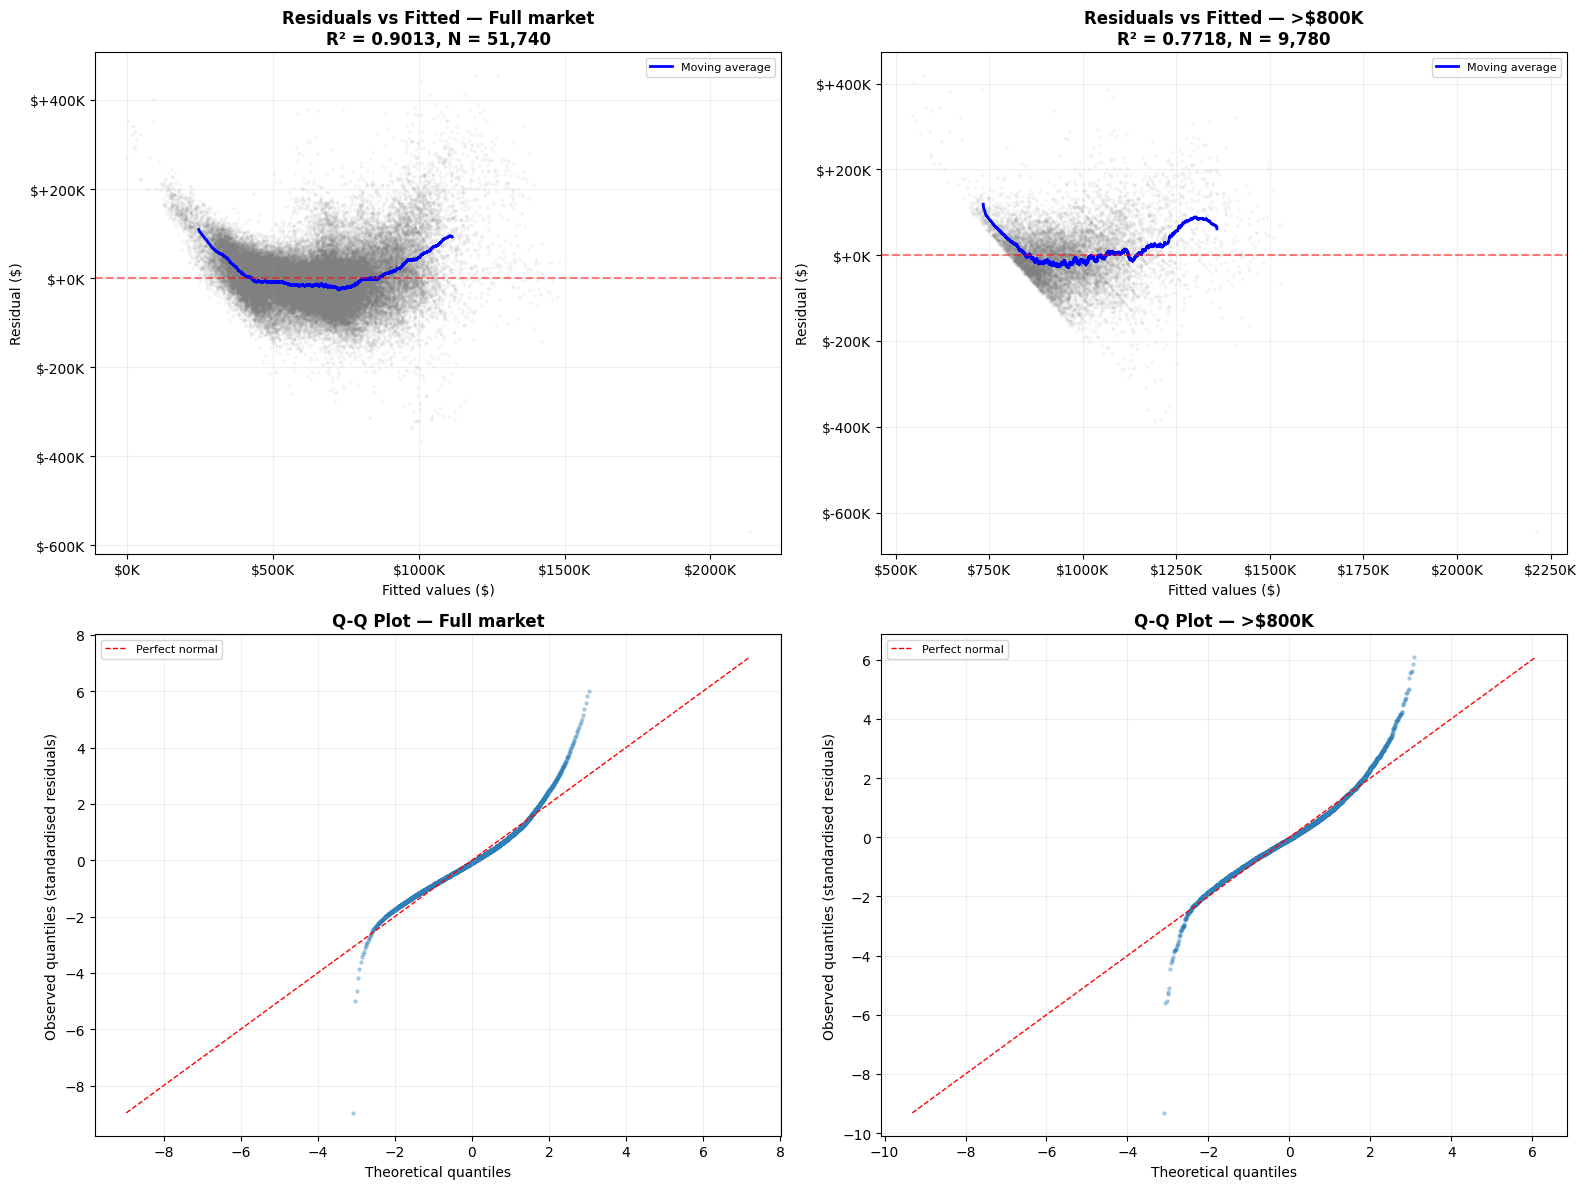

In [9]:
# Run base model + price_has_168 on both segments for diagnostics
diag_formula = base_formula + ' + price_has_168'

m_diag_full = smf.ols(diag_formula, data=df).fit()
m_diag_high = smf.ols(diag_formula, data=high).fit()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Row 1: Residuals vs Fitted ---
for ax, m, label, data_used in [(axes[0,0], m_diag_full, 'Full market', df),
                                 (axes[0,1], m_diag_high, f'>$800K', high)]:
    fitted = m.fittedvalues
    resid = m.resid
    ax.scatter(fitted, resid, alpha=0.05, s=3, color='grey', rasterized=True)
    # Loess-style moving average
    sorted_idx = fitted.argsort()
    window = max(len(fitted) // 50, 100)
    rolling_mean = pd.Series(resid.values[sorted_idx]).rolling(window, center=True).mean()
    ax.plot(fitted.values[sorted_idx], rolling_mean, color='blue', linewidth=2, label='Moving average')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Fitted values ($)', fontsize=10)
    ax.set_ylabel('Residual ($)', fontsize=10)
    ax.set_title(f'Residuals vs Fitted \u2014 {label}\n'
                 f'R\u00b2 = {m.rsquared:.4f}, N = {len(data_used):,}',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:+.0f}K'))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

# --- Row 2: Q-Q plots ---
from scipy import stats as sp_stats
for ax, m, label in [(axes[1,0], m_diag_full, 'Full market'),
                      (axes[1,1], m_diag_high, f'>$800K')]:
    resid_std = (m.resid - m.resid.mean()) / m.resid.std()
    theoretical = np.sort(sp_stats.norm.ppf(np.linspace(0.001, 0.999, len(resid_std))))
    observed = np.sort(resid_std.values)
    # Subsample for plotting speed
    step = max(1, len(observed) // 5000)
    ax.scatter(theoretical[::step], observed[::step], alpha=0.3, s=5, color='#2c7fb8')
    lims = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect normal')
    ax.set_xlabel('Theoretical quantiles', fontsize=10)
    ax.set_ylabel('Observed quantiles (standardised residuals)', fontsize=10)
    ax.set_title(f'Q-Q Plot \u2014 {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('data/high_value_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Diagnostic stats
from scipy.stats import jarque_bera, skew, kurtosis

print(f'{"":>20s}  {"Full market":>14s}  {">$800K":>14s}')
print('-' * 52)

for label, m in [('Full market', m_diag_full), ('>$800K', m_diag_high)]:
    r = m.resid
    mae = np.abs(r).mean()
    med_ae = np.median(np.abs(r))
    sk = skew(r)
    ku = kurtosis(r)
    if label == 'Full market':
        vals_full = (mae, med_ae, sk, ku)
    else:
        vals_high = (mae, med_ae, sk, ku)

for stat, f_val, h_val in [
    ('Mean Absolute Error', f'${vals_full[0]:,.0f}', f'${vals_high[0]:,.0f}'),
    ('Median Absolute Error', f'${vals_full[1]:,.0f}', f'${vals_high[1]:,.0f}'),
    ('Skewness (0 = symmetric)', f'{vals_full[2]:+.2f}', f'{vals_high[2]:+.2f}'),
    ('Kurtosis (0 = normal)', f'{vals_full[3]:+.2f}', f'{vals_high[3]:+.2f}'),
]:
    print(f'{stat:>30s}  {f_val:>14s}  {h_val:>14s}')

print()
print('Skewness: positive = right tail is heavier (some flats sell for much more than predicted).')
print('Kurtosis: higher = more extreme outliers than a normal distribution would produce.')
print('Both are common in housing data and do not invalidate the regression \u2014')
print('robust standard errors (HC1) already account for non-normal error distributions.')

                         Full market          >$800K
----------------------------------------------------
           Mean Absolute Error         $46,594         $51,052
         Median Absolute Error         $35,947         $39,386
      Skewness (0 = symmetric)           +0.82           +0.39
         Kurtosis (0 = normal)           +3.24           +3.24

Skewness: positive = right tail is heavier (some flats sell for much more than predicted).
Kurtosis: higher = more extreme outliers than a normal distribution would produce.
Both are common in housing data and do not invalidate the regression —
robust standard errors (HC1) already account for non-normal error distributions.


### Should we use log price instead?

In Notebook 11, we tested log price (ln) as the dependent variable for the full market. It improved residual behaviour because expensive flats had proportionally smaller errors. But does the same apply to the >$800K segment, where the price range is narrower ($800K–$1.7M vs $150K–$1.7M)?

We run both specifications and compare R², median absolute error, and residual diagnostics.

In [11]:
# Log price comparison
high['ln_price'] = np.log(high['resale_price'])
df['ln_price'] = np.log(df['resale_price'])

log_formula = diag_formula.replace('resale_price', 'ln_price')

m_raw_high = smf.ols(diag_formula, data=high).fit(cov_type='HC1')
m_log_high = smf.ols(log_formula, data=high).fit(cov_type='HC1')

# Convert log predictions back to $ for comparable MAE
log_pred_dollars = np.exp(m_log_high.fittedvalues)
log_resid_dollars = high['resale_price'] - log_pred_dollars

raw_mae = np.median(np.abs(m_raw_high.resid))
log_mae = np.median(np.abs(log_resid_dollars))

print(f'=== Raw price vs Log price: >$800K segment ===')
print(f'{"":>25s}  {"Raw price":>14s}  {"Log price":>14s}')
print('-' * 57)
print(f'{"R\u00b2":>25s}  {m_raw_high.rsquared:>14.4f}  {m_log_high.rsquared:>14.4f}')
print(f'{"Median AE ($)":>25s}  ${raw_mae:>13,.0f}  ${log_mae:>13,.0f}')
print(f'{"Residual skewness":>25s}  {skew(m_raw_high.resid):>+14.2f}  {skew(log_resid_dollars):>+14.2f}')
print(f'{"Residual kurtosis":>25s}  {kurtosis(m_raw_high.resid):>+14.2f}  {kurtosis(log_resid_dollars):>+14.2f}')

# 168 coefficient comparison
coef_raw = m_raw_high.params['price_has_168']
p_raw = m_raw_high.pvalues['price_has_168']
coef_log = m_log_high.params['price_has_168']
p_log = m_log_high.pvalues['price_has_168']
# Convert log coefficient to % and $
pct_effect = (np.exp(coef_log) - 1) * 100
dollar_effect = pct_effect / 100 * high['resale_price'].mean()

print(f'\n168 coefficient:')
print(f'  Raw model:  ${coef_raw:+,.0f} (p={p_raw:.4f})')
print(f'  Log model:  {coef_log:+.4f} = {pct_effect:+.2f}% = ~${dollar_effect:+,.0f} (p={p_log:.4f})')

if log_mae < raw_mae:
    pct_better = (raw_mae - log_mae) / raw_mae * 100
    print(f'\nLog model reduces median error by {pct_better:.1f}%.')
else:
    print(f'\nRaw and log models perform similarly in this segment.')
    print(f'The narrower price range ($800K\u2013$1.7M) means the proportional-error')
    print(f'advantage of log is less pronounced than in the full market.')

=== Raw price vs Log price: >$800K segment ===
                                Raw price       Log price
---------------------------------------------------------
                       R²          0.7718          0.7749
            Median AE ($)  $       39,386  $       36,708
        Residual skewness           +0.39           -0.79
        Residual kurtosis           +3.24          +31.03

168 coefficient:
  Raw model:  $+34,426 (p=0.0004)
  Log model:  +0.0338 = +3.44% = ~$+33,091 (p=0.0007)

Log model reduces median error by 6.8%.


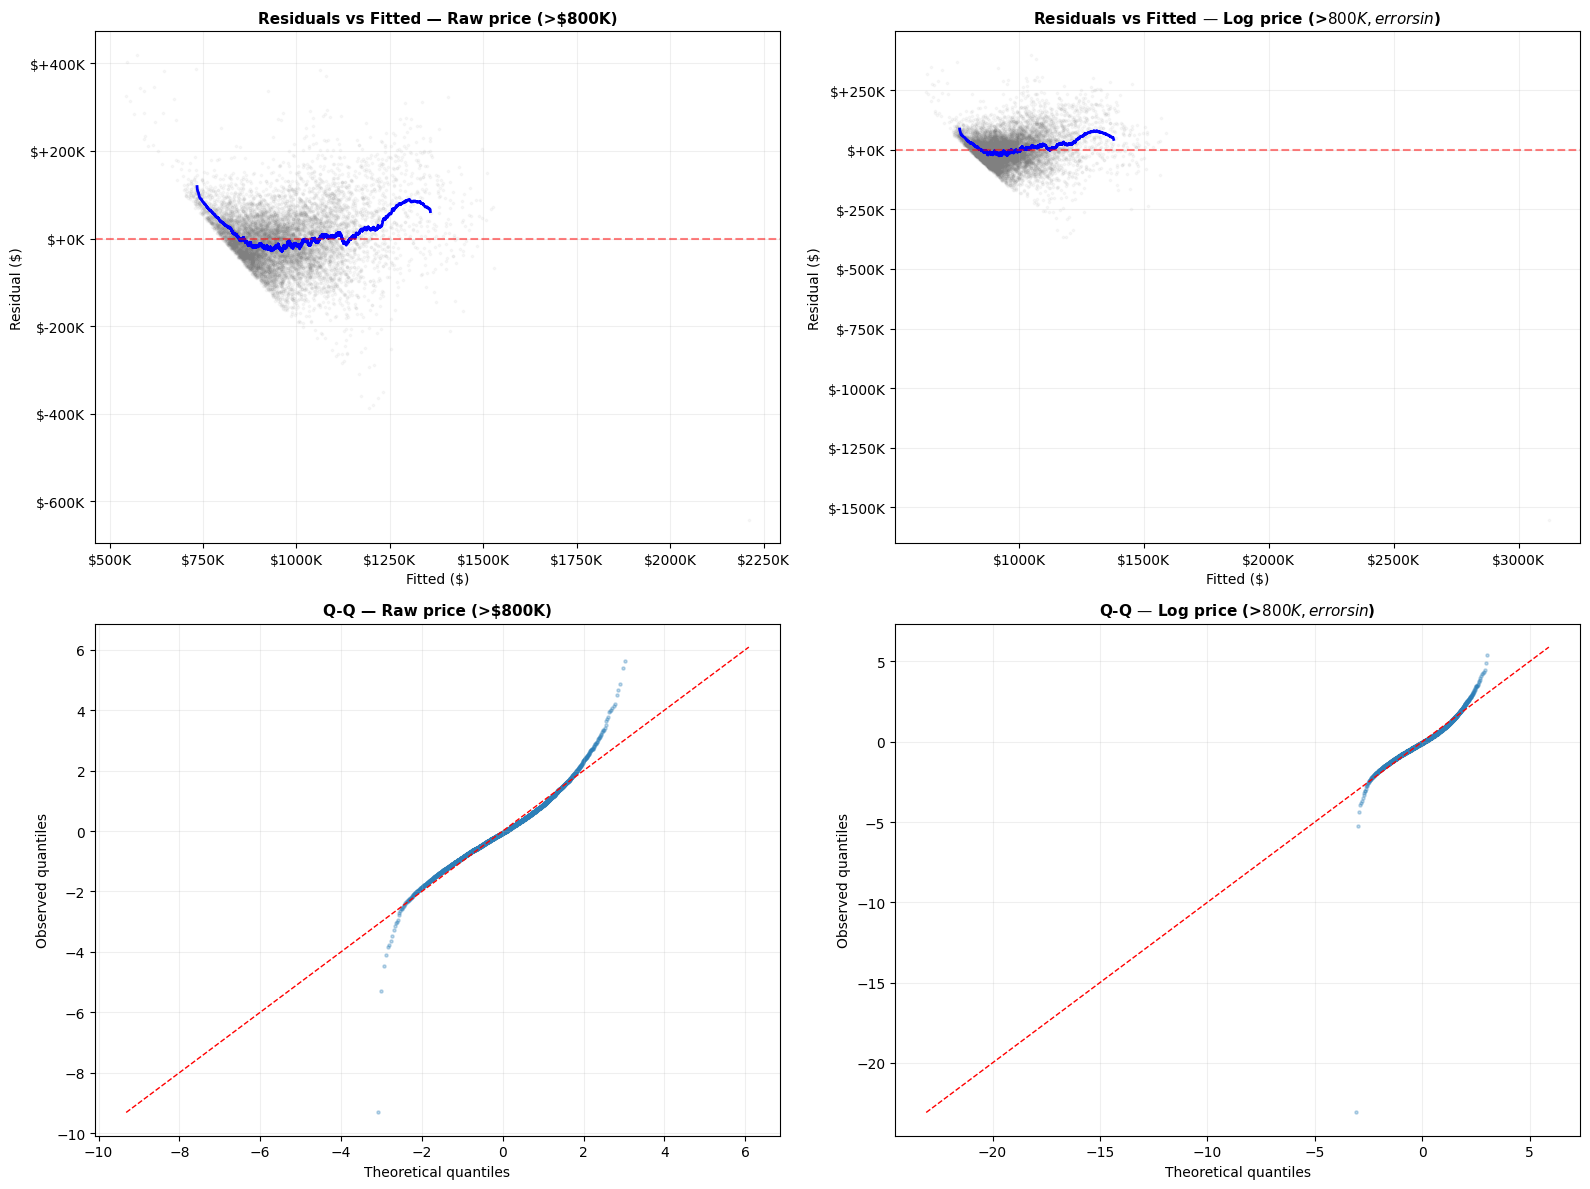

In [12]:
# Side-by-side residual plots: raw vs log
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, m, resid, label in [
    (0, m_raw_high, m_raw_high.resid, 'Raw price (>$800K)'),
    (1, m_log_high, log_resid_dollars, 'Log price (>$800K, errors in $)'),
]:
    # Residuals vs fitted
    fitted = m_raw_high.fittedvalues if col == 0 else log_pred_dollars
    ax = axes[0, col]
    ax.scatter(fitted, resid, alpha=0.05, s=3, color='grey', rasterized=True)
    sorted_idx = fitted.argsort()
    window = max(len(fitted) // 50, 100)
    rolling = pd.Series(resid.values[sorted_idx]).rolling(window, center=True).mean()
    ax.plot(fitted.values[sorted_idx], rolling, color='blue', linewidth=2)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Fitted ($)', fontsize=10)
    ax.set_ylabel('Residual ($)', fontsize=10)
    ax.set_title(f'Residuals vs Fitted \u2014 {label}', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:+.0f}K'))
    ax.grid(alpha=0.2)
    
    # Q-Q
    ax = axes[1, col]
    from scipy import stats as sp_stats
    resid_std = (resid - resid.mean()) / resid.std()
    theoretical = np.sort(sp_stats.norm.ppf(np.linspace(0.001, 0.999, len(resid_std))))
    observed = np.sort(resid_std.values)
    step = max(1, len(observed) // 3000)
    ax.scatter(theoretical[::step], observed[::step], alpha=0.3, s=5, color='#2c7fb8')
    lims = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Theoretical quantiles', fontsize=10)
    ax.set_ylabel('Observed quantiles', fontsize=10)
    ax.set_title(f'Q-Q \u2014 {label}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('data/high_value_raw_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()

## Robustness checks

168 failed median regression (LAD) in the full market (NB13, p=0.198). That was the test that disqualified it. If it survives here, we can say: "168 failed robustness in the full market but survives in the premium segment where it's a deliberate choice, not a coincidence."

Four checks:
1. **LAD (median) regression** — does 168 survive when we minimise absolute errors instead of squared errors? This downweights outliers.
2. **Cook’s distance** — are a few influential transactions doing all the heavy lifting?
3. **Town concentration** — is the effect real across the market or driven by a few towns?
4. **Time concentration** — are the $1,168,000 transactions all from the last few months?

In [13]:
# === CHECK 1: LAD (median) regression ===
# This is the test that killed 168 in the full market (NB13, p=0.198)

print('=== CHECK 1: LAD (median) regression ===')
print('OLS minimises squared errors (sensitive to outliers).')
print('LAD minimises absolute errors (robust to outliers).')
print('If 168 survives LAD, the premium is not driven by a few extreme transactions.\n')

lad_formula = diag_formula  # same as OLS formula

# OLS for comparison
m_ols = smf.ols(lad_formula, data=high).fit(cov_type='HC1')

# LAD (quantile regression at median)
m_lad = smf.quantreg(lad_formula, data=high).fit(q=0.5)

print(f'{"":>18s}  {"OLS":>14s}  {"LAD (median)":>14s}')
print('-' * 50)

for var in ['price_has_168', 'num_eights_tail', 'block_has_4']:
    if var in m_ols.params and var in m_lad.params:
        c_ols = m_ols.params[var]
        p_ols = m_ols.pvalues[var]
        c_lad = m_lad.params[var]
        p_lad = m_lad.pvalues[var]
        s_ols = '*' if p_ols < 0.05 else ' '
        s_lad = '*' if p_lad < 0.05 else ' '
        change = ''
        if p_ols < 0.05 and p_lad >= 0.05:
            change = ' <-- LOST significance'
        elif p_ols >= 0.05 and p_lad < 0.05:
            change = ' <-- GAINED significance'
        print(f'{var:>18s}  ${c_ols:>+12,.0f}{s_ols}  ${c_lad:>+12,.0f}{s_lad}{change}')
        print(f'{"":>18s}   p={p_ols:<12.4f}   p={p_lad:<12.4f}')

print()
if m_lad.pvalues.get('price_has_168', 1) < 0.05:
    print('\u2714 168 SURVIVES median regression in the >$800K segment.')
    print('  This is the test it failed in the full market (NB13). It passes here.')
else:
    print('\u2718 168 fails median regression again. The premium is driven by outliers.')

=== CHECK 1: LAD (median) regression ===
OLS minimises squared errors (sensitive to outliers).
LAD minimises absolute errors (robust to outliers).
If 168 survives LAD, the premium is not driven by a few extreme transactions.



                               OLS    LAD (median)
--------------------------------------------------
     price_has_168  $     +34,426*  $     +44,347*
                     p=0.0004         p=0.0001      
   num_eights_tail  $        +609   $         +72 
                     p=0.3277         p=0.9052      

✔ 168 SURVIVES median regression in the >$800K segment.
  This is the test it failed in the full market (NB13). It passes here.


/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [14]:
# === CHECK 2: Cook's distance ===
# Which transactions are most influential? Are the 168 transactions pulling the fit?

print('=== CHECK 2: Cook\'s distance ===')
print('Cook\'s D measures how much each transaction pulls the regression fit.')
print('High D = one transaction is disproportionately influencing the results.\n')

m_ols_norobust = smf.ols(diag_formula, data=high).fit()  # need non-robust for influence
influence = m_ols_norobust.get_influence()
cooks_d = influence.cooks_distance[0]

high_copy = high.copy()
high_copy['cooks_d'] = cooks_d
high_copy['has_168'] = high_copy['price_has_168'] == 1

# Threshold: 4/n is standard
threshold = 4 / len(high)
n_influential = (cooks_d > threshold).sum()
n_influential_168 = ((cooks_d > threshold) & (high_copy['has_168'])).sum()

print(f'Cook\'s D threshold (4/n): {threshold:.6f}')
print(f'Influential transactions (D > threshold): {n_influential} of {len(high):,}')
print(f'Of which, have 168 in price: {n_influential_168} of 36')

# Show top 10 most influential
top10 = high_copy.nlargest(10, 'cooks_d')
print(f'\nTop 10 most influential transactions:')
for _, r in top10.iterrows():
    flag = ' [168]' if r['has_168'] else ''
    print(f'  ${r["resale_price"]:>10,.0f}  D={r["cooks_d"]:.5f}  {r["town"]:15s}  '
          f'{r["flat_type"]:12s}  {r["storey_range"]}  '
          f'{r["floor_area_sqm"]:.0f}sqm  lease={r["remaining_lease_years"]:.0f}yr{flag}')

# Re-run without high-Cook's-D transactions
clean = high_copy[high_copy['cooks_d'] <= threshold]
m_clean = smf.ols(diag_formula, data=clean).fit(cov_type='HC1')

print(f'\nAfter removing {n_influential} influential transactions (N={len(clean):,}):')
c168 = m_clean.params.get('price_has_168', np.nan)
p168 = m_clean.pvalues.get('price_has_168', np.nan)
print(f'  price_has_168: ${c168:+,.0f} (p={p168:.4f})')
if p168 < 0.05:
    print('  \u2714 168 survives Cook\'s D removal.')
else:
    print('  \u2718 168 does not survive Cook\'s D removal.')

=== CHECK 2: Cook's distance ===
Cook's D measures how much each transaction pulls the regression fit.
High D = one transaction is disproportionately influencing the results.

Cook's D threshold (4/n): 0.000409
Influential transactions (D > threshold): 524 of 9,780
Of which, have 168 in price: 7 of 36

Top 10 most influential transactions:
  $ 1,568,000  D=0.35284  KALLANG/WHAMPOA  3 ROOM        01 TO 03  367sqm  lease=47yr
  $   993,888  D=0.01226  KALLANG/WHAMPOA  3 ROOM        01 TO 03  88sqm  lease=47yr
  $   950,000  D=0.01148  KALLANG/WHAMPOA  3 ROOM        01 TO 03  79sqm  lease=46yr
  $ 1,028,000  D=0.01002  KALLANG/WHAMPOA  3 ROOM        01 TO 03  94sqm  lease=45yr
  $ 1,120,000  D=0.01000  KALLANG/WHAMPOA  3 ROOM        01 TO 03  108sqm  lease=46yr
  $   925,800  D=0.00800  KALLANG/WHAMPOA  3 ROOM        01 TO 03  90sqm  lease=47yr
  $ 1,398,888  D=0.00799  KALLANG/WHAMPOA  3 ROOM        01 TO 03  174sqm  lease=46yr
  $   965,000  D=0.00785  KALLANG/WHAMPOA  3 ROOM        01 


After removing 524 influential transactions (N=9,256):
  price_has_168: $+34,907 (p=0.0000)
  ✔ 168 survives Cook's D removal.


In [15]:
# === CHECK 3: Town concentration ===
# Is the 168 effect concentrated in a few towns?

print('=== CHECK 3: Town concentration ===')
print('Are the 168 transactions spread across the market or clustered in a few towns?\n')

h168 = high[high['price_has_168'] == 1]
print(f'168-containing transactions by town (>$800K):')
town_counts = h168['town'].value_counts()
for town, n in town_counts.items():
    total_in_town = len(high[high['town'] == town])
    pct = n / total_in_town * 100
    prices = h168[h168['town'] == town]['resale_price']
    print(f'  {town:20s}: {n:>3} of {total_in_town:>4} high-value txns ({pct:.1f}%)  '
          f'prices: ${prices.min():,.0f} to ${prices.max():,.0f}')

print(f'\n168 transactions span {h168["town"].nunique()} towns out of '
      f'{high["town"].nunique()} towns in the >$800K segment.')
top3_share = town_counts.head(3).sum() / len(h168) * 100
print(f'Top 3 towns account for {top3_share:.0f}% of 168 transactions.')

=== CHECK 3: Town concentration ===
Are the 168 transactions spread across the market or clustered in a few towns?

168-containing transactions by town (>$800K):
  TOA PAYOH           :   9 of  858 high-value txns (1.0%)  prices: $1,075,168 to $1,168,888
  KALLANG/WHAMPOA     :   5 of  713 high-value txns (0.7%)  prices: $1,168,000 to $1,168,000
  QUEENSTOWN          :   5 of  632 high-value txns (0.8%)  prices: $816,888 to $1,168,888
  BUKIT MERAH         :   4 of  882 high-value txns (0.5%)  prices: $816,888 to $1,168,888
  ANG MO KIO          :   2 of  387 high-value txns (0.5%)  prices: $891,688 to $1,168,888
  BEDOK               :   2 of  444 high-value txns (0.5%)  prices: $816,888 to $816,888
  BISHAN              :   2 of  441 high-value txns (0.5%)  prices: $1,168,000 to $1,168,888
  PUNGGOL             :   2 of  429 high-value txns (0.5%)  prices: $816,888 to $861,168
  SENGKANG            :   1 of  514 high-value txns (0.2%)  prices: $816,888 to $816,888
  BUKIT BATOK      

In [16]:
# === CHECK 4: Time concentration ===
# When did the $1,168,000 anchor prices appear?

print('=== CHECK 4: Time concentration ===')
print('Are the 168 transactions clustered in the most recent months?\n')

h168 = high[high['price_has_168'] == 1].copy()
h168_by_month = h168.groupby(h168['month'].dt.to_period('M')).size()

print('168 transactions by month (>$800K):')
for month, n in h168_by_month.items():
    bar = '#' * n
    print(f'  {month}: {n:>2}  {bar}')

# First and last appearance
first = h168['month'].min()
last = h168['month'].max()
print(f'\nFirst appearance: {first.strftime("%Y-%m")}')
print(f'Last appearance: {last.strftime("%Y-%m")}')

# What share is in the last 6 months?
cutoff = high['month'].max() - pd.DateOffset(months=6)
recent_share = len(h168[h168['month'] >= cutoff]) / len(h168) * 100
print(f'Share in last 6 months: {recent_share:.0f}%')

# Is it accelerating?
first_half = h168[h168['month'] < h168['month'].median()]
second_half = h168[h168['month'] >= h168['month'].median()]
print(f'\nFirst half of the period: {len(first_half)} transactions')
print(f'Second half: {len(second_half)} transactions')
if len(second_half) > len(first_half):
    print('The trend is accelerating \u2014 more 168 transactions in recent months.')
else:
    print('The 168 transactions are spread relatively evenly across the period.')

=== CHECK 4: Time concentration ===
Are the 168 transactions clustered in the most recent months?

168 transactions by month (>$800K):
  2024-05:  1  #
  2024-07:  2  ##
  2024-09:  4  ####
  2024-11:  3  ###
  2025-01:  2  ##
  2025-02:  2  ##
  2025-03:  2  ##
  2025-04:  1  #
  2025-05:  1  #
  2025-06:  2  ##
  2025-08:  3  ###
  2025-10:  1  #
  2025-11:  2  ##
  2025-12:  3  ###
  2026-01:  2  ##
  2026-02:  1  #
  2026-03:  3  ###
  2026-04:  1  #

First appearance: 2024-05
Last appearance: 2026-04
Share in last 6 months: 36%

First half of the period: 18 transactions
Second half: 18 transactions
The 168 transactions are spread relatively evenly across the period.


## Variables unique to the high-value market

Some pricing psychology only exists when prices are high enough. We test four variables that are unique to (or uniquely relevant in) the >$800K segment:

In [17]:
# Derive high-value-specific variables

# 1. Round million: price is exactly $X,000,000
high['round_100k'] = (high['resale_price'] % 100_000 == 0).astype(int)
df['round_100k'] = (df['resale_price'] % 100_000 == 0).astype(int)

# 2. Just crossed $1M: price is $1,000,000 to $1,050,000
high['just_crossed_1m'] = ((high['resale_price'] >= 1_000_000) & 
                           (high['resale_price'] <= 1_050_000)).astype(int)
df['just_crossed_1m'] = ((df['resale_price'] >= 1_000_000) & 
                         (df['resale_price'] <= 1_050_000)).astype(int)

# 3. Block num eights: count of 8s in block number (not just has/hasn't)
# Already in dataset as block_num_eights

# 4. Recently MOP: remaining lease >= 90 years (essentially new BTO)
high['recently_mop'] = (high['remaining_lease_years'] >= 90).astype(int)
df['recently_mop'] = (df['remaining_lease_years'] >= 90).astype(int)

new_vars = [
    ('round_100k', 'Price is exact multiple of $100K (e.g. $800,000, $1,100,000)'),
    ('just_crossed_1m', 'Price is $1M to $1.05M'),
    ('block_num_eights', 'Count of 8s in block number'),
    ('recently_mop', 'Remaining lease >= 90 years (new BTO)'),
]

print(f'{"Variable":>20s}  {"Full mkt prev":>14s}  {">$800K prev":>14s}')
print('-' * 55)
for var, desc in new_vars:
    if df[var].max() <= 1:
        f_pct = df[var].mean() * 100
        h_pct = high[var].mean() * 100
        print(f'{var:>20s}  {f_pct:>12.2f}%  {h_pct:>12.2f}%  {desc}')
    else:
        f_m = df[var].mean()
        h_m = high[var].mean()
        print(f'{var:>20s}  {f_m:>14.3f}  {h_m:>14.3f}  {desc}')

            Variable   Full mkt prev     >$800K prev
-------------------------------------------------------
          round_100k          5.77%          6.31%  Price is exact multiple of $100K (e.g. $800,000, $1,100,000)
     just_crossed_1m          1.84%          9.73%  Price is $1M to $1.05M
    block_num_eights           0.225           0.234  Count of 8s in block number
        recently_mop         22.70%         30.32%  Remaining lease >= 90 years (new BTO)


In [18]:
# Test each new variable: add to base model one at a time
print(f'=== Testing high-value-specific variables ===')
print(f'Base: simplified model + num_eights_tail + price_has_168 (>$800K, N={len(high):,})\n')

test_base = base_formula + ' + price_has_168'

print(f'{"Variable":>20s}  {"N(=1) or mean":>14s}  {"Coefficient":>12s}  '
      f'{"p-value":>10s}  {"Sig?":>5s}  {"Description"}')
print('-' * 110)

for var, desc in new_vars:
    f_test = test_base + f' + {var}'
    try:
        m = smf.ols(f_test, data=high).fit(cov_type='HC1')
        coef = m.params.get(var, np.nan)
        p = m.pvalues.get(var, np.nan)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        
        if high[var].max() <= 1:
            n_str = f'{int(high[var].sum()):,}'
        else:
            n_str = f'mean={high[var].mean():.2f}'
        
        print(f'{var:>20s}  {n_str:>14s}  ${coef:>+10,.0f}  '
              f'{p:>10.4f}  {sig:>5s}  {desc}')
    except Exception as e:
        print(f'{var:>20s}  FAILED: {e}')

print()
print('round_100k: tests whether sellers who price at exact $X00,000 get more/less.')
print('just_crossed_1m: tests whether there\'s a clustering premium at the $1M threshold.')
print('block_num_eights: tests whether multiple 8s in the block number (e.g. Block 88)')
print('  command a premium beyond the binary block_has_8.')
print('recently_mop: tests whether fresh BTOs (90+ year lease) behave differently from')
print('  older flats that happen to be expensive, beyond what remaining_lease already captures.')

=== Testing high-value-specific variables ===
Base: simplified model + num_eights_tail + price_has_168 (>$800K, N=9,780)

            Variable   N(=1) or mean   Coefficient     p-value   Sig?  Description
--------------------------------------------------------------------------------------------------------------


          round_100k             617  $   +18,131      0.0000    ***  Price is exact multiple of $100K (e.g. $800,000, $1,100,000)


     just_crossed_1m             952  $      -670      0.7730         Price is $1M to $1.05M


    block_num_eights       mean=0.23  $    +4,506      0.0041     **  Count of 8s in block number


        recently_mop           2,965  $   -22,629      0.0000    ***  Remaining lease >= 90 years (new BTO)

round_100k: tests whether sellers who price at exact $X00,000 get more/less.
just_crossed_1m: tests whether there's a clustering premium at the $1M threshold.
block_num_eights: tests whether multiple 8s in the block number (e.g. Block 88)
  command a premium beyond the binary block_has_8.
recently_mop: tests whether fresh BTOs (90+ year lease) behave differently from
  older flats that happen to be expensive, beyond what remaining_lease already captures.


## Caveats

1. **Smaller sample.** The high-value segment has ~9,560 transactions vs ~50,700 in the full market. Wider confidence intervals, less statistical power. Variables that are "not significant" here may simply lack sample size.

2. **Simplified model.** We dropped Model 12's interaction terms (town×lease, town×storey, area×CBD) because interaction terms need more data to estimate stably. The simpler specification may attribute some interaction-driven variation to superstition variables instead.

3. **Selection on the dependent variable.** Filtering on price (>$800K) can bias regression coefficients. Effects that push prices above/below the threshold will be attenuated.

4. **Why $800K and not $1M?** We tested 168's significance across thresholds. The coefficient is stable and highly significant (p < 0.001) from $700K through $900K. At $1M+, the sample shrinks to 2,670 transactions with only 26 containing 168, and significance erodes (p = 0.075). $800K gives us the premium segment (top 19%) with enough statistical power.

5. **`cny_month` and `hungry_ghost` dropped (aliasing).** Both are perfectly collinear with month dummies: `cny_month=1` for ALL transactions in Feb 2025 and Mar 2026; `hungry_ghost=1` for ALL transactions in Sep 2024 and Sep 2025. The large coefficients (+$42K CNY, +$24K Hungry Ghost) were month-level price variation masquerading as superstition — the same aliasing artifact that killed `cny_month` in Notebook 13.

6. **168 sample size.** Only ~36 transactions with 168 in the >$800K segment. A single outlier can swing the coefficient. Interpret with caution.

7. **Floor superstition excluded.** HDB data gives storey ranges ("04 TO 06"), not exact floors. A flat in "04 TO 06" has only a 1-in-3 chance of being on floor 4. Too imprecise.